In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import Normalize
from scipy.stats import gaussian_kde


In [2]:
def V(x, y):

    term1 = -17.3 * np.exp(-0.0039 * (x - 48)**2 - 0.0391 * (y - 8)**2)
    term2 = -8.7 * np.exp(-0.0039 * (x - 32)**2 - 0.0391 * (y - 16)**2)
    term3 = -14.7 * np.exp(-0.0254 * (x - 24)**2 + 0.043 * (x - 24) * (y - 32) - 0.0254 * (y - 32)**2)
    term4 = 1.3 * np.exp(0.00273 * (x - 16)**2 + 0.0023 * (x - 16) * (y - 24) + 0.00273 * (y - 24)**2)
    
    return term1 + term2 + term3 + term4

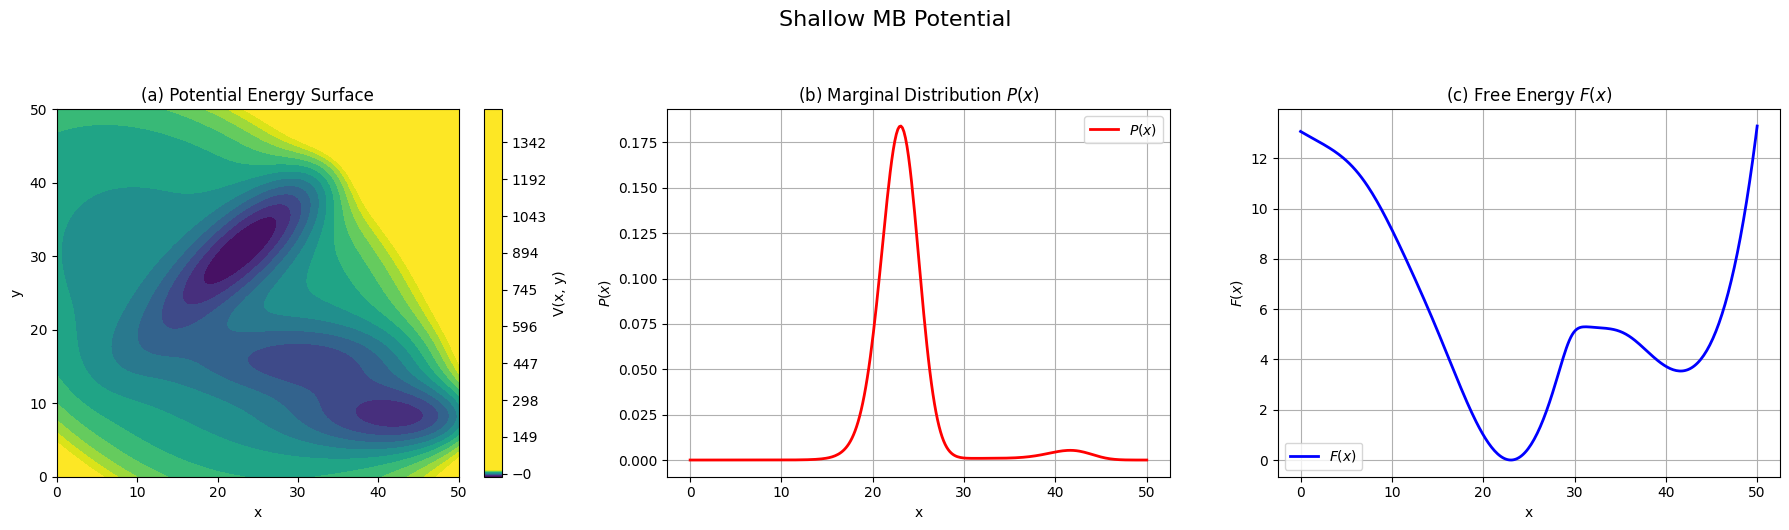

In [ ]:
# Grid for 2D potential surface
x_vals = np.linspace(0, 50, 300)
y_vals = np.linspace(0, 50, 300)
X, Y = np.meshgrid(x_vals, y_vals)
Z = V(X, Y)

# Compute marginal distribution P(x)
beta = 1.0 / 1.0
P_x = np.array([quad(lambda y: np.exp(-V(x, y) * beta), 0, 50)[0] for x in x_vals])
P_x /= np.trapz(P_x, x_vals)  # Normalize

# Compute free energy F(x)
F_x = -np.log(P_x) / beta
F_x -= F_x.min()  # Set min free energy to 0

# Create 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle("MB Potential", fontsize=16, y=1.05)

# Plot (a): Potential landscape
cmap = plt.get_cmap("viridis")
levels = np.linspace(np.min(Z), np.max(Z), 600)
norm = Normalize(vmin=np.min(levels), vmax=15)
c = axs[0].contourf(X, Y, Z, levels=levels, cmap=cmap, norm=norm)
axs[0].set_title("(a) Potential Energy Surface")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
fig.colorbar(c, ax=axs[0], label="V(x, y)")

# Plot (b): Marginal distribution
axs[1].plot(x_vals, P_x, lw=2, color='red', label="$P(x)$")
axs[1].set_title("(b) Marginal Distribution $P(x)$")
axs[1].set_xlabel("x")
axs[1].set_ylabel("$P(x)$")
axs[1].grid(True)
axs[1].legend()

# Plot (c): Free energy F(x)
axs[2].plot(x_vals, F_x, lw=2, color='blue', label="$F(x)$")
axs[2].set_title("(c) Free Energy $F(x)$")
axs[2].set_xlabel("x")
axs[2].set_ylabel("$F(x)$")
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

(5000000, 1)
<class 'numpy.ndarray'>


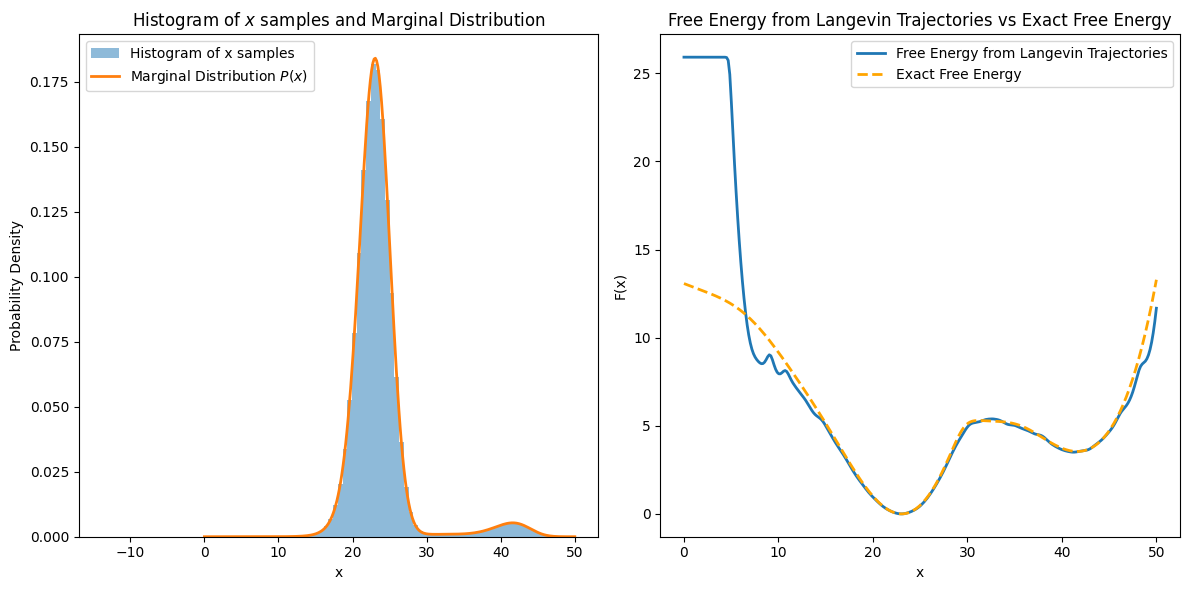

In [ ]:
data = np.load("mb_unbiased.npz")
data = dict(data)
positions = data["data"][:, 0:1]
print(positions.shape)
print(type(positions))

# Free energy from Langevin trajectories
x_samples = positions[..., 0]
x_samples = x_samples.flatten()
kde = gaussian_kde(x_samples[::100])
x_grid = np.linspace(-0, 50, 300)
F_x_samples = -np.log(kde(x_grid) + 1e-12) / beta
F_x_samples -= np.min(F_x_samples)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# (a) Histogram and marginal distribution
axs[0].hist(x_samples, bins=100, density=True, alpha=0.5, label="Histogram of x samples")
axs[0].plot(x_vals, P_x, lw=2, label="Marginal Distribution $P(x)$")
axs[0].set_xlabel("x")
axs[0].set_ylabel("Probability Density")
axs[0].set_title("Histogram of $x$ samples and Marginal Distribution")
axs[0].legend()

# (b) Free energy comparison
axs[1].plot(x_grid, F_x_samples, lw=2, label="Free Energy from Langevin Trajectories")
axs[1].plot(x_vals, F_x, lw=2, linestyle='--', color='orange', label="Exact Free Energy")
axs[1].set_title("Free Energy from Langevin Trajectories vs Exact Free Energy")
axs[1].set_xlabel("x")
axs[1].set_ylabel(r"F(x)")
axs[1].legend()

plt.tight_layout()
plt.show()